In [4]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("alldata_new.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

import sys
import os

module_path = os.path.abspath(os.path.join("../../src/"))
if module_path not in sys.path:
    sys.path.append(module_path)

from HubbardTweezer.Hubbard.lattice import sqr_lattice

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([4, 4]))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

Vi = dat["t_ij"].diagonal(axis1=1, axis2=2)

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

3001
1190


# Anlysis

## Trap depth

Text(0, 0.5, 'V')

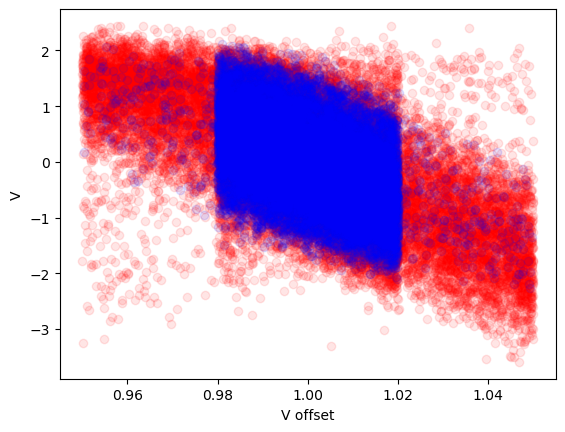

In [7]:
plt.scatter(
    dat["V_offset"][~mask].flatten(),
    Vi[~mask].flatten(),
    color="r",
    alpha=0.1,
)
plt.scatter(
    dat["V_offset"][mask].flatten(),
    Vi[mask].flatten(),
    color="b",
    alpha=0.1,
)
plt.xlabel("V offset")
plt.ylabel("V")

## Positions

### No. of neighbours

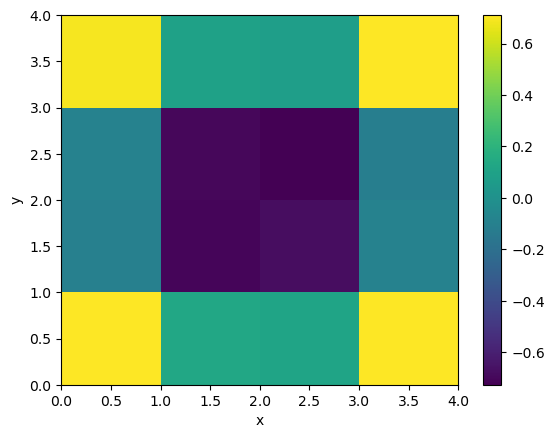

In [8]:
avgV = np.mean(Vi[mask], axis=0)
plt.pcolormesh(avgV.reshape(4, 4))
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()

In [ ]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr

nno = nneighbor(width, height)
avgr = avg_trap_spacing(np.arange(width * height)).T

In [26]:
avgV = np.mean(Vi[mask], axis=0)

Text(0, 0.5, 'U_i')

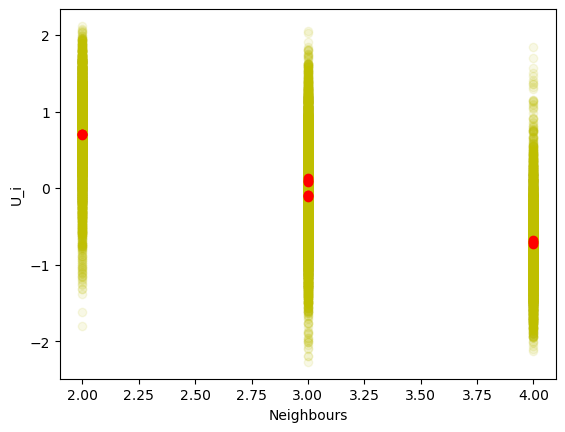

In [28]:
sidx = list(range(16))
plt.scatter(
    np.tile(nno, nmask), Vi[mask][:, sidx].flatten(), color="y", alpha=0.1
)
plt.scatter(nno, avgV[sidx].flatten(), color="r", alpha=1)
plt.xlabel("Neighbours")
plt.ylabel("U_i")

There is a dependence of V_i on trap neighbor number.

Study the correlation of V_offset dependence on the number of neighbours.

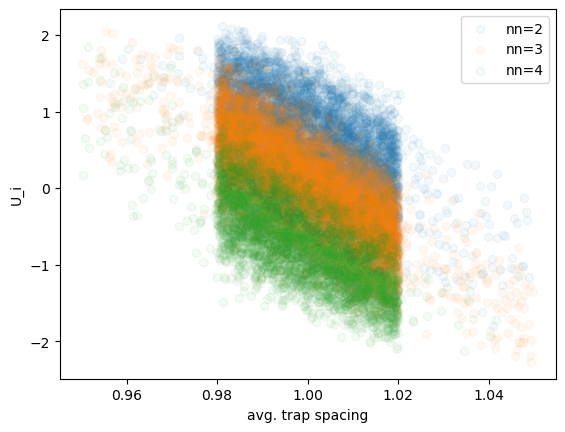

In [ ]:
for i in [2, 3, 4]:
    plt.scatter(
        dat["V_offset"][mask][:, nno == i],
        Vi[mask][:, nno == i].flatten(),
        alpha=5e-2,
        label=f"nn={i}",
    )
plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

The V_offset slope has no clear dependence on the neighboring number.

### Avg. trap spacing

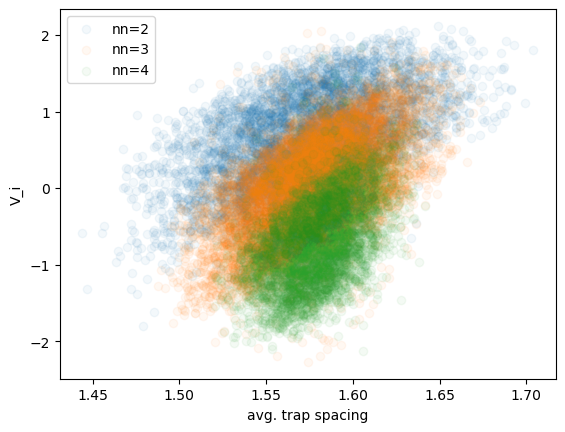

In [48]:
for i in [2, 3, 4]:
    plt.scatter(
        avgr[:, nno == i], Vi[mask][:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}"
    )
plt.xlabel("avg. trap spacing")
plt.ylabel("V_i")
plt.legend()

The dependence seems to be more complex. Less clear dependence on trap spacing.

In [31]:
from typing import Iterable


def tot_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([tot_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    totr = np.sum(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return totr


totr = tot_trap_spacing(np.arange(16)).T

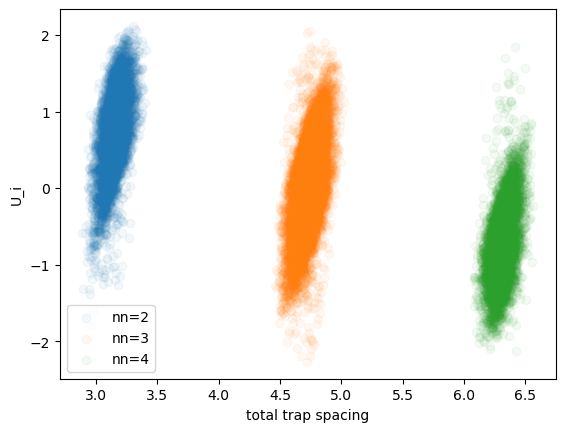

In [32]:
for i in [2, 3, 4]:
    plt.scatter(totr[:, nno == i], Vi[mask][:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}")
plt.xlabel("total trap spacing")
plt.ylabel("U_i")
plt.legend()

### 

# Fitting the data

## Model with trap depth and trap neighbor number

In [39]:
X = dat["V_offset"][mask]
Y = Vi[mask]

In [40]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr

nno = nneighbor(width, height)
avgr = avg_trap_spacing(np.arange(width * height)).T

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter
        self.c = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        return self.a * x["V_offset"] + self.b * x["nn"] + self.c


# Convert data to torch tensors
# X_torch = torch.tensor(np.log(X), dtype=torch.float32)
# Y_torch = torch.tensor(np.log(Y), dtype=torch.float32)
X_torch = {}
X_torch["V_offset"] = torch.tensor(X, dtype=torch.float64)
# X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nno, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
b = model.b.item()
c = model.c.item()

print(f"Model: Y = {a} * X + {b} * nno + {c}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.2872
Epoch [2/1000], Loss: 0.2825
Epoch [3/1000], Loss: 0.2825
Epoch [4/1000], Loss: 0.2825
Final Loss: 0.2825
Model: Y = -34.622440338134766 * X + -0.7672441601753235 * nno + 36.92518997192383
R^2 Score: 0.7175068394355668


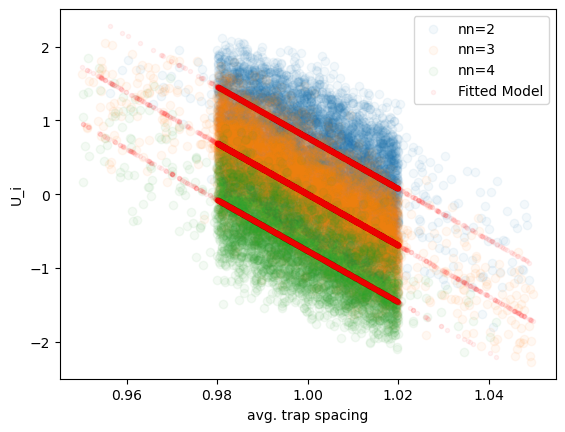

In [46]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(X[:, nno == i], Y[:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}")
# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=5e-2)

plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

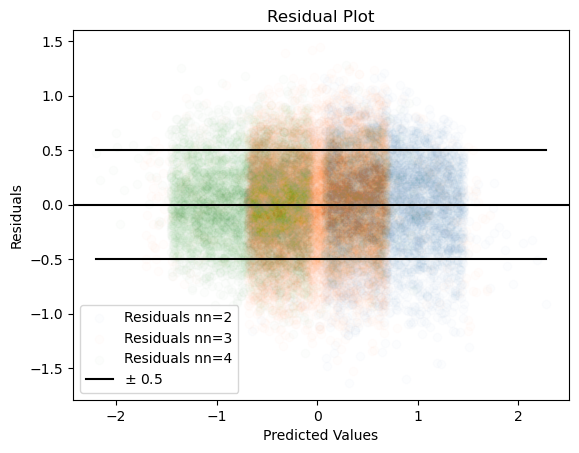

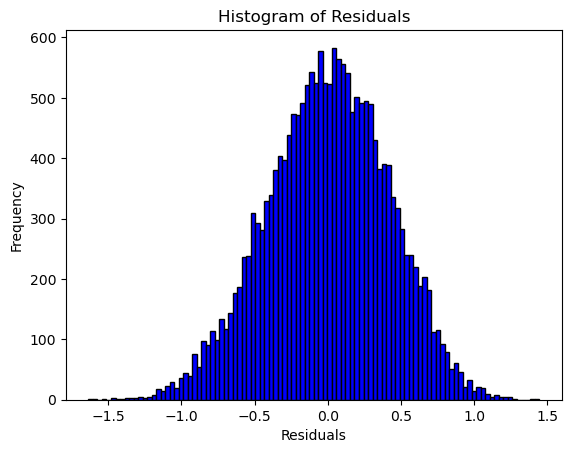

In [47]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=1e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.5 * np.ones_like(x), color="k", label="$\pm$ 0.5")
plt.plot(x, -0.5 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np.flatten(), bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

## Model with above and trap spacing

In [11]:
X = dat["V_offset"][mask]
Y = Vi[mask]

In [12]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr

nno = nneighbor(width, height)
avgr = avg_trap_spacing(np.arange(width * height)).T

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.a = nn.Parameter(torch.randn((2,)))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter
        self.c = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        a = self.a[0] * x["nn"][None] + self.a[1]
        b = self.b[0] * x["nn"][None] + self.b[1]
        c = self.c[0] * x["nn"][None] + self.c[1]
        return a * x["V_offset"] + b * x["avgr"] + c


# Convert data to torch tensors
# X_torch = torch.tensor(np.log(X), dtype=torch.float32)
# Y_torch = torch.tensor(np.log(Y), dtype=torch.float32)
X_torch = {}
X_torch["V_offset"] = torch.tensor(X, dtype=torch.float64)
X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nno, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a
b = model.b
c = model.c

print(
    f"Exponential model: Y = ({a[0]} * nno + {a[1]}) * X + ({b[0]} * nno + {b[1]}) * avgr + ({c[0]} * nno + {c[1]})"
)
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.0772
Epoch [2/1000], Loss: 0.0648
Epoch [3/1000], Loss: 0.0629
Epoch [4/1000], Loss: 0.0629
Final Loss: 0.0629
Exponential model: Y = (0.19835832715034485 * nno + -37.29949951171875) * X + (3.1387290954589844 * nno + 3.290590524673462) * avgr + (-5.9599199295043945 * nno + 34.54936599731445)
R^2 Score: 0.9371234704340416


The X slope dependence on nno is not obvious ~1/200.

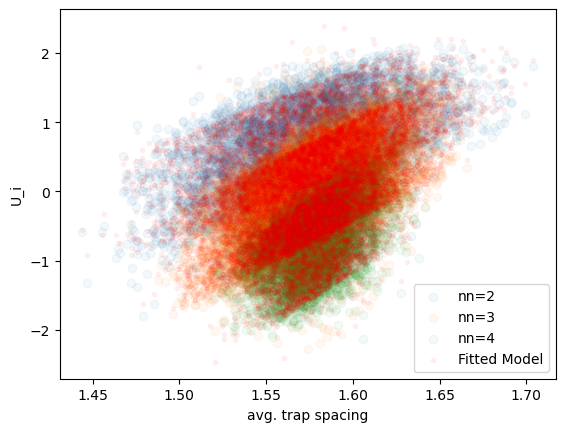

In [17]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(avgr[:, nno == i], Y[:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}")
# Plotting the model's predictions
plt.scatter(avgr, predicted, color="red", label="Fitted Model", marker=".", alpha=5e-2)

plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

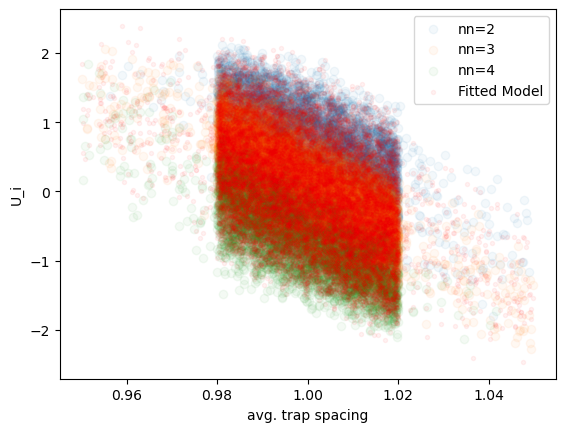

In [18]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(X[:, nno == i], Y[:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}")
# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=5e-2)

plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

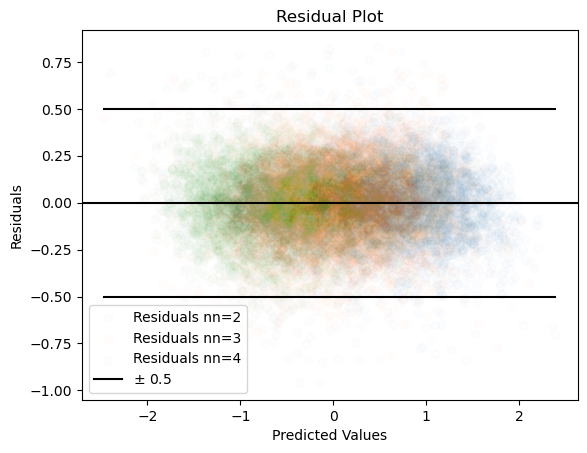

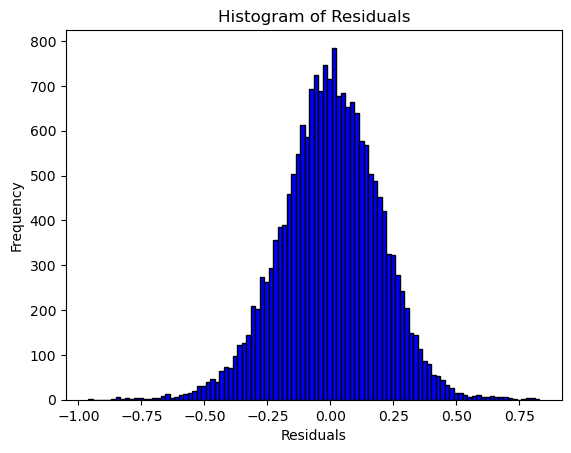

In [25]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=1e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.5 * np.ones_like(x), color="k", label="$\pm$ 0.5")
plt.plot(x, -0.5 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np.flatten(), bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")